Outcomes:
By the end of this assignment, you should be able to implement sequence models using PyTorch.
Instructions:
On the same IMDb movie review dataset that you used in the previous lab, apply a RNN, LSTM and a
Bidirectional-LSTM based model.
1. Model - Modify the model for text classification that you had implemented. Ensure that your
model includes an Embedding layer, at least one RNN/LSTM/BiLSTM layer and a fully
connected layer. Initialize the embedding layer with pretrained embeddings.
2. Setup - Continue using the same dataset, loss function and optimizer for training the network.
3. Record the loss, accuracy and average gradient magnitude of the first layer (closest to input)
while training.
4. Experiments - Try to vary the following and observe the impact on classification performance:
a. Number of RNN/LSTM/BiLSTM layers
b. Size of hidden state
c. Embeddings - try to use OneHot instead of Word2Vec
5. Compare - Plot a comparison of loss, accuracy and average gradient magnitude between all the
three sequence models. Compare these models to the CNN that you implemented in the previous
lab.
Submission guidelines:
- Prepare a jupyter notebook file containing the following:
- Code & outputs of various tasks assigned.
- Your observations in brief, explaining the output of each task.
- Ensure that each task has clear headings and outputs are visible for all cells.
- Export it as a pdf and upload it to Google Classroom.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
!pip install gensim
import gensim
print('Gensim version:', gensim.__version__)

Gensim version: 4.4.0


In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import gensim.downloader as api
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# --- 1. Load Data ---
import os
import urllib.request

file_path = "IMDB Dataset.csv"
if not os.path.exists(file_path):
    print("Downloading IMDB dataset...")
    url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
    urllib.request.urlretrieve(url, file_path)

# Using a subset for faster debugging and execution
raw_data = pd.read_csv(file_path)
reviews = raw_data['review'].values

# --- 2. Build Vocabulary ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

word_counts = Counter()
for review in reviews:
    word_counts.update(clean_text(review))

word_to_idx = {word: i + 2 for i, (word, _) in enumerate(word_counts.most_common())}
word_to_idx['<PAD>'] = 0
word_to_idx['<UNK>'] = 1
vocab_size = len(word_to_idx)
print(f"Final Vocab Size: {vocab_size}")

# --- 3. Pretrained Word2Vec Embeddings ---
print("Downloading/Loading pretrained Word2Vec embeddings (Google News 300)...")
w2v_vectors = api.load("word2vec-google-news-300")

emb = torch.zeros(vocab_size, 300)
for word, idx in word_to_idx.items():
    if word in w2v_vectors:
        emb[idx] = torch.tensor(w2v_vectors[word].copy())
    else:
        emb[idx] = torch.randn(300)

# --- 4. Prepare and Split Dataset ---
max_length = 200
def encode_review(text):
    words = clean_text(text)
    encoded = [word_to_idx.get(w, 1) for w in words]
    if len(encoded) < max_length: encoded = encoded + [0] * (max_length - len(encoded))
    else: encoded = encoded[:max_length]
    return encoded

padded_reviews = np.array([encode_review(r) for r in reviews])
labels = raw_data["sentiment"].map({"positive" : 1, "negative" : 0}).values

X_train, X_test, y_train, y_test = train_test_split(
    padded_reviews, labels, test_size = 0.1, stratify = labels, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size = 0.1, stratify = y_train, random_state=42
)

train_ds = TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).float().unsqueeze(1))
val_ds = TensorDataset(torch.from_numpy(X_val).long(), torch.from_numpy(y_val).float().unsqueeze(1))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

Final Vocab Size: 166765
Downloading/Loading pretrained Word2Vec embeddings (Google News 300)...


## Model1
### 0. tried using the last output from each node which gave bad results due to final output getting malformed due to all the 0 padding tokens

### 1. then using maxPool to get the highest activation value along all the time 't', but it disregards the sequence of text

In [ ]:
class TextModel1(nn.Module):
    """Baseline RNN/LSTM with max pooling to handle variable-length sequences."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pretrained_emb, model_type="LSTM", bidirectional=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight.data.copy_(pretrained_emb)
        # Freeze the embedding layer
        self.embedding.weight.requires_grad = True # to also train the embedding layer

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)

        direction = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        output, _ = self.rnn(x)

        # take last timestep
        # out = output[:, -1, :]
        out, _ = torch.max(output, dim=1)

        # Applying sigmoid here so the output is a probability for BCELoss
        return torch.sigmoid(self.fc(out))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Re-enable GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-initialize models on the proper device
models = {
    "RNN": TextModel1(vocab_size, 300, 128, 1, emb, "RNN"),
    "LSTM": TextModel1(vocab_size, 300, 128, 1, emb, "LSTM"),
    "BiLSTM": TextModel1(vocab_size, 300, 128, 1, emb, "LSTM", bidirectional=True)
}

results = {}
EPOCHS = 3
LOG_STEPS = 100
EVAL_STEPS = 100

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    train_loss_history = []
    val_acc_history = []
    grad_mags = []

    for epoch in range(EPOCHS):
        model.train()
        for step, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()

            # Grad magnitude of first layer (RNN/LSTM layer 1 weights)
            grad = next(model.rnn.parameters()).grad
            if grad is not None:
                grad_mags.append(grad.abs().mean().item())
            else:
                grad_mags.append(0.0)

            optimizer.step()
            train_loss_history.append(loss.item())

            if (step + 1) % LOG_STEPS == 0:
                print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end="")

            if (step + 1) % EVAL_STEPS == 0:
                model.eval()
                val_correct, val_total = 0, 0
                with torch.no_grad():
                    for X_v, y_v in val_loader:
                        X_v, y_v = X_v.to(device), y_v.to(device)
                        p_v = model(X_v)
                        val_correct += ((p_v > 0.5).float() == y_v).sum().item()
                        val_total += y_v.size(0)
                val_acc = val_correct / val_total
                val_acc_history.append(val_acc)
                print(f" | Val Acc: {val_acc:.4f}")
                model.train()

    results[name] = {
        'train_loss': train_loss_history,
        'val_acc': val_acc_history,
        'grads': grad_mags
    }

Using device: cuda

--- Training RNN ---
Epoch: [1/3] | Step: [100/317] | Loss: 0.6775 | Val Acc: 0.6291
Epoch: [1/3] | Step: [200/317] | Loss: 0.5702 | Val Acc: 0.6822
Epoch: [1/3] | Step: [300/317] | Loss: 0.4910 | Val Acc: 0.7969
Epoch: [2/3] | Step: [100/317] | Loss: 0.2820 | Val Acc: 0.8369
Epoch: [2/3] | Step: [200/317] | Loss: 0.2739 | Val Acc: 0.8589
Epoch: [2/3] | Step: [300/317] | Loss: 0.2483 | Val Acc: 0.8629
Epoch: [3/3] | Step: [100/317] | Loss: 0.1508 | Val Acc: 0.8651
Epoch: [3/3] | Step: [200/317] | Loss: 0.1848 | Val Acc: 0.8709
Epoch: [3/3] | Step: [300/317] | Loss: 0.1931 | Val Acc: 0.8702

--- Training LSTM ---
Epoch: [1/3] | Step: [100/317] | Loss: 0.5149 | Val Acc: 0.7691
Epoch: [1/3] | Step: [200/317] | Loss: 0.2992 | Val Acc: 0.8587
Epoch: [1/3] | Step: [300/317] | Loss: 0.2654 | Val Acc: 0.8673
Epoch: [2/3] | Step: [100/317] | Loss: 0.2104 | Val Acc: 0.8642
Epoch: [2/3] | Step: [200/317] | Loss: 0.2475 | Val Acc: 0.8753
Epoch: [2/3] | Step: [300/317] | Loss: 0

In [ ]:
# Create test loader
test_ds = TensorDataset(torch.from_numpy(X_test).long(), torch.from_numpy(y_test).float().unsqueeze(1))
test_loader = DataLoader(test_ds, batch_size=128)

### test accuracy

In [ ]:
print("--- Final Evaluation on Test Set ---")
for name, model in models.items():
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)

            logits = model(X_batch_test)
            # Assuming BCELoss was requested and model has sigmoid:
            loss = criterion(logits, y_batch_test)
            test_loss += loss.item()

            preds = (logits > 0.5).float()
            test_correct += (preds == y_batch_test).sum().item()
            test_total += y_batch_test.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    print(f"{name:6} | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f}")

--- Final Evaluation on Test Set ---
RNN    | Test Loss: 0.3198 | Test Acc: 0.8684
LSTM   | Test Loss: 0.3472 | Test Acc: 0.8700
BiLSTM | Test Loss: 0.3695 | Test Acc: 0.8638


### plots

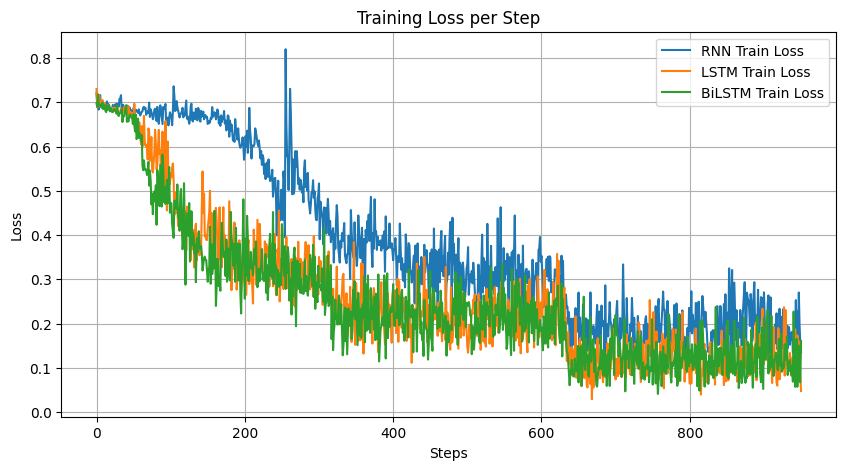

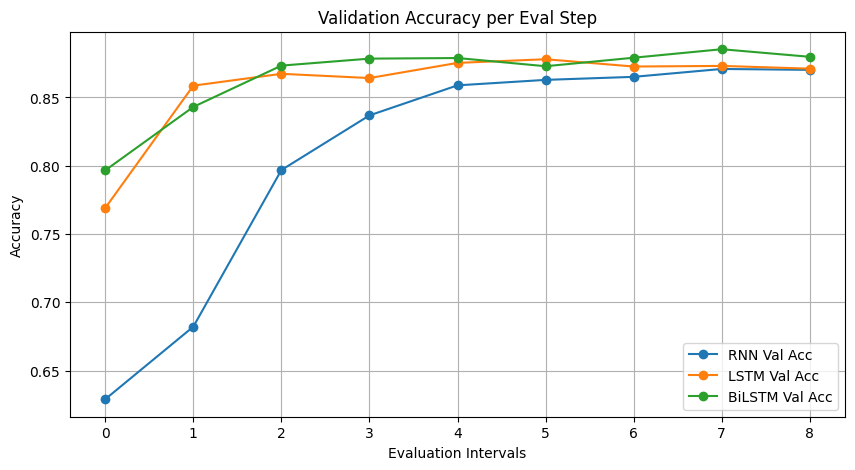

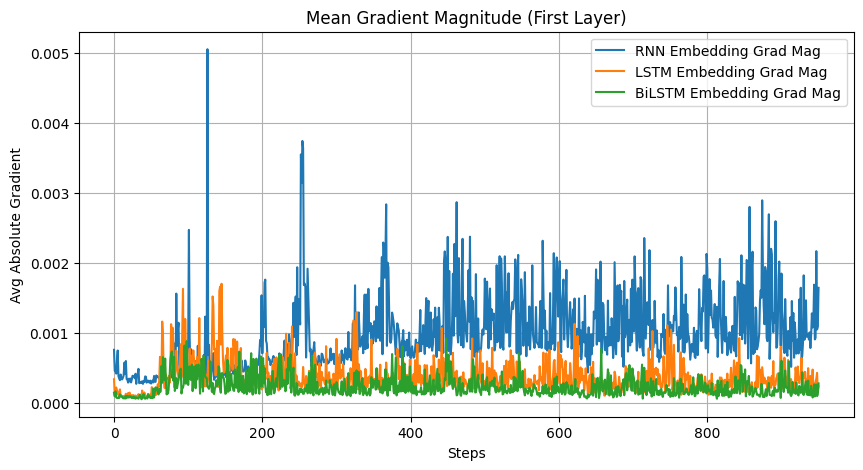

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Training Loss
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['train_loss'], label=f"{name} Train Loss")
plt.title("Training Loss per Step")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Validation Accuracy
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['val_acc'], label=f"{name} Val Acc", marker='o')
plt.title("Validation Accuracy per Eval Step")
plt.xlabel("Evaluation Intervals")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 3. Plot Gradient Magnitudes
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['grads'], label=f"{name} Embedding Grad Mag")
plt.title("Mean Gradient Magnitude (First Layer)")
plt.xlabel("Steps")
plt.ylabel("Avg Absolute Gradient")
plt.legend()
plt.grid(True)
plt.show()

## Model2

### 2. Using the industry standard `pack_padded_sequence`

In [ ]:
class TextModel2(nn.Module):
    """Improved version using pack_padded_sequence to ignore padding tokens during RNN computation."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pretrained_emb, model_type="LSTM", bidirectional=False):
        super().__init__()

        self.model_type = model_type
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight.data.copy_(pretrained_emb)
        self.embedding.weight.requires_grad = True

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)

        direction = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction, output_dim)

    def forward(self, x, lengths):
        # 1. Embed and apply dropout
        embedded = self.embedding(x)

        # 2. Pack the sequence (Ignore the padding zeros during computation)
        # enforce_sorted=False allows us to pass un-sorted batches
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # 3. Process through RNN/LSTM
        if self.model_type == "RNN":
            _, hidden = self.rnn(packed_embedded)
        else:
            _, (hidden, cell) = self.rnn(packed_embedded)

        # 4. Extract the true final hidden state
        if self.bidirectional:
            # Concat the final forward state [-2] and final backward state [-1]
            hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        else:
            # Take the final forward state
            hidden = hidden[-1, :, :]

        # 5. Classify
        return torch.sigmoid(self.fc(hidden))

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models = {
    "RNN": TextModel2(vocab_size, 300, 128, 1, emb, "RNN"),
    "LSTM": TextModel2(vocab_size, 300, 128, 1, emb, "LSTM"),
    "BiLSTM": TextModel2(vocab_size, 300, 128, 1, emb, "LSTM", bidirectional=True)
}

results = {}
EPOCHS = 3
LOG_STEPS = 100
EVAL_STEPS = 100

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    train_loss_history = []
    val_acc_history = []
    grad_mags = []

    for epoch in range(EPOCHS):
        model.train()
        for step, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Calculate actual lengths (non-zero tokens) for pack_padded_sequence
            lengths = (X_batch != 0).sum(dim=1)
            # Ensure lengths are at least 1 for packing
            lengths[lengths == 0] = 1

            optimizer.zero_grad()
            # Fix: Pass lengths to the forward method
            preds = model(X_batch, lengths)
            loss = criterion(preds, y_batch)
            loss.backward()

            grad = next(model.rnn.parameters()).grad
            if grad is not None:
                grad_mags.append(grad.abs().mean().item())
            else:
                grad_mags.append(0.0)

            optimizer.step()
            train_loss_history.append(loss.item())

            if (step + 1) % LOG_STEPS == 0:
                print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end="")

            if (step + 1) % EVAL_STEPS == 0:
                model.eval()
                val_correct, val_total = 0, 0
                with torch.no_grad():
                    for X_v, y_v in val_loader:
                        X_v, y_v = X_v.to(device), y_v.to(device)
                        l_v = (X_v != 0).sum(dim=1)
                        l_v[l_v == 0] = 1
                        p_v = model(X_v, l_v)
                        val_correct += ((p_v > 0.5).float() == y_v).sum().item()
                        val_total += y_v.size(0)
                val_acc = val_correct / val_total
                val_acc_history.append(val_acc)
                print(f" | Val Acc: {val_acc:.4f}")
                model.train()

    results[name] = {
        'train_loss': train_loss_history,
        'val_acc': val_acc_history,
        'grads': grad_mags
    }

Using device: cuda

--- Training RNN ---
Epoch: [1/3] | Step: [100/317] | Loss: 0.7425 | Val Acc: 0.6284
Epoch: [1/3] | Step: [200/317] | Loss: 0.5883 | Val Acc: 0.7133
Epoch: [1/3] | Step: [300/317] | Loss: 0.5146 | Val Acc: 0.7529
Epoch: [2/3] | Step: [100/317] | Loss: 0.4739 | Val Acc: 0.7736
Epoch: [2/3] | Step: [200/317] | Loss: 0.6199 | Val Acc: 0.6118
Epoch: [2/3] | Step: [300/317] | Loss: 0.5847 | Val Acc: 0.7167
Epoch: [3/3] | Step: [100/317] | Loss: 0.5036 | Val Acc: 0.7529
Epoch: [3/3] | Step: [200/317] | Loss: 0.5131 | Val Acc: 0.6782
Epoch: [3/3] | Step: [300/317] | Loss: 0.6065 | Val Acc: 0.6022

--- Training LSTM ---
Epoch: [1/3] | Step: [100/317] | Loss: 0.6033 | Val Acc: 0.7451
Epoch: [1/3] | Step: [200/317] | Loss: 0.4769 | Val Acc: 0.7667
Epoch: [1/3] | Step: [300/317] | Loss: 0.5358 | Val Acc: 0.7736
Epoch: [2/3] | Step: [100/317] | Loss: 0.4237 | Val Acc: 0.8084
Epoch: [2/3] | Step: [200/317] | Loss: 0.4609 | Val Acc: 0.7949
Epoch: [2/3] | Step: [300/317] | Loss: 0

### test accuracy

In [ ]:
print("--- Final Evaluation on Test Set ---")
for name, model in models.items():
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)

            # Calculate lengths for pack_padded_sequence
            lengths = (X_batch_test != 0).sum(dim=1)
            lengths[lengths == 0] = 1

            logits = model(X_batch_test, lengths)
            loss = criterion(logits, y_batch_test)
            test_loss += loss.item()

            preds = (logits > 0.5).float()
            test_correct += (preds == y_batch_test).sum().item()
            test_total += y_batch_test.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    print(f"{name:6} | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f}")

--- Final Evaluation on Test Set ---
RNN    | Test Loss: 0.3198 | Test Acc: 0.8684
LSTM   | Test Loss: 0.3472 | Test Acc: 0.8700
BiLSTM | Test Loss: 0.3695 | Test Acc: 0.8638


### plots

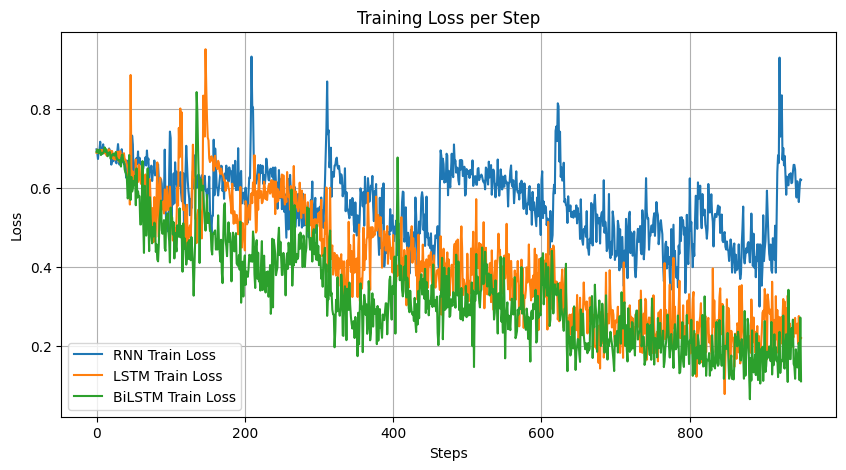

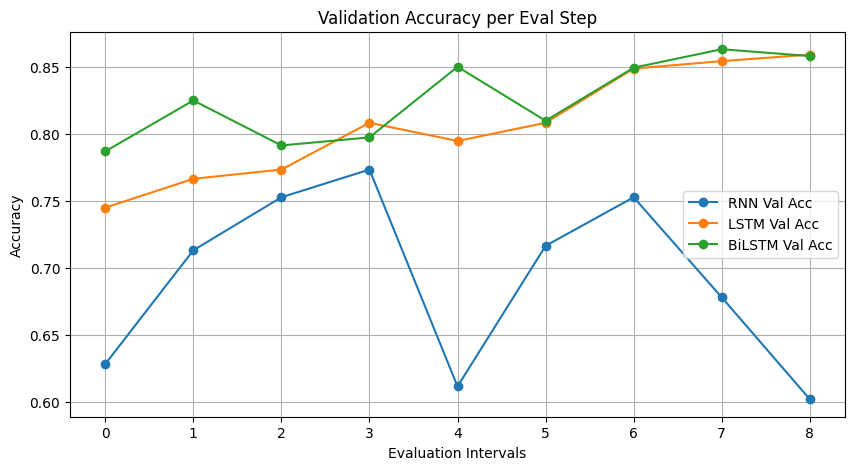

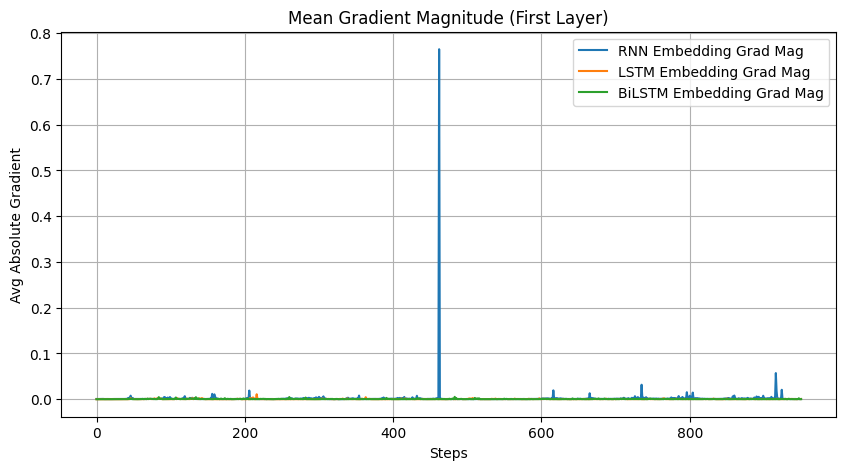

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Training Loss
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['train_loss'], label=f"{name} Train Loss")
plt.title("Training Loss per Step")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Validation Accuracy
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['val_acc'], label=f"{name} Val Acc", marker='o')
plt.title("Validation Accuracy per Eval Step")
plt.xlabel("Evaluation Intervals")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 3. Plot Gradient Magnitudes
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['grads'], label=f"{name} Embedding Grad Mag")
plt.title("Mean Gradient Magnitude (First Layer)")
plt.xlabel("Steps")
plt.ylabel("Avg Absolute Gradient")
plt.legend()
plt.grid(True)
plt.show()

## Model3
### `pack_padded_sequence` +  dropOut

In [ ]:
class TextModel3(nn.Module):
    """Model2 + dropout regularization (0.5) to reduce overfitting on full sequences."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pretrained_emb, model_type="LSTM", bidirectional=False):
        super().__init__()

        self.model_type = model_type
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight.data.copy_(pretrained_emb)
        self.embedding.weight.requires_grad = True

        # Regularization: 50% chance to zero out neurons to prevent overfitting
        self.dropout = nn.Dropout(0.5)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)

        direction = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction, output_dim)

    def forward(self, x, lengths):
        # 1. Embed and apply dropout
        embedded = self.dropout(self.embedding(x))

        # 2. Pack the sequence (Ignore the padding zeros during computation)
        # enforce_sorted=False allows us to pass un-sorted batches
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # 3. Process through RNN/LSTM
        if self.model_type == "RNN":
            _, hidden = self.rnn(packed_embedded)
        else:
            _, (hidden, cell) = self.rnn(packed_embedded)

        # 4. Extract the true final hidden state
        if self.bidirectional:
            # Concat the final forward state [-2] and final backward state [-1]
            hidden = self.dropout(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        else:
            # Take the final forward state
            hidden = self.dropout(hidden[-1, :, :])

        # 5. Classify
        return torch.sigmoid(self.fc(hidden))

In [ ]:
# Re-enable GPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-initialize models on the proper device
models = {
    "RNN": TextModel3(vocab_size, 300, 128, 1, emb, "RNN"),
    "LSTM": TextModel3(vocab_size, 300, 128, 1, emb, "LSTM"),
    "BiLSTM": TextModel3(vocab_size, 300, 128, 1, emb, "LSTM", bidirectional=True)
}

results = {}
EPOCHS = 3
LOG_STEPS = 100
EVAL_STEPS = 100

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    train_loss_history = []
    val_acc_history = []
    grad_mags = []

    for epoch in range(EPOCHS):
        model.train()
        for step, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Calculate actual lengths for pack_padded_sequence
            lengths = (X_batch != 0).sum(dim=1)
            lengths[lengths == 0] = 1

            optimizer.zero_grad()
            # Fix: Pass lengths to Model3
            preds = model(X_batch, lengths)
            loss = criterion(preds, y_batch)
            loss.backward()

            # Grad magnitude of first layer (RNN/LSTM layer 1 weights)
            grad = next(model.rnn.parameters()).grad
            if grad is not None:
                grad_mags.append(grad.abs().mean().item())
            else:
                grad_mags.append(0.0)

            optimizer.step()
            train_loss_history.append(loss.item())

            if (step + 1) % LOG_STEPS == 0:
                print(f"Epoch: [{epoch+1}/{EPOCHS}] | Step: [{step+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end="")

            if (step + 1) % EVAL_STEPS == 0:
                model.eval()
                val_correct, val_total = 0, 0
                with torch.no_grad():
                    for X_v, y_v in val_loader:
                        X_v, y_v = X_v.to(device), y_v.to(device)
                        l_v = (X_v != 0).sum(dim=1)
                        l_v[l_v == 0] = 1
                        p_v = model(X_v, l_v)
                        val_correct += ((p_v > 0.5).float() == y_v).sum().item()
                        val_total += y_v.size(0)
                val_acc = val_correct / val_total
                val_acc_history.append(val_acc)
                print(f" | Val Acc: {val_acc:.4f}")
                model.train()

    results[name] = {
        'train_loss': train_loss_history,
        'val_acc': val_acc_history,
        'grads': grad_mags
    }

### test accuracy

In [ ]:
print("--- Final Evaluation on Test Set ---")
for name, model in models.items():
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X_batch_test, y_batch_test in test_loader:
            X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)

            # Calculate lengths for pack_padded_sequence (used by Model 2 and Model 3)
            lengths = (X_batch_test != 0).sum(dim=1)
            lengths[lengths == 0] = 1

            # Fix: Pass both X and lengths
            logits = model(X_batch_test, lengths)

            loss = criterion(logits, y_batch_test)
            test_loss += loss.item()

            preds = (logits > 0.5).float()
            test_correct += (preds == y_batch_test).sum().item()
            test_total += y_batch_test.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    print(f"{name:6} | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f}")

--- Final Evaluation on Test Set ---
RNN    | Test Loss: 0.6482 | Test Acc: 0.6068
LSTM   | Test Loss: 0.3918 | Test Acc: 0.8538
BiLSTM | Test Loss: 0.3998 | Test Acc: 0.8444


### plots

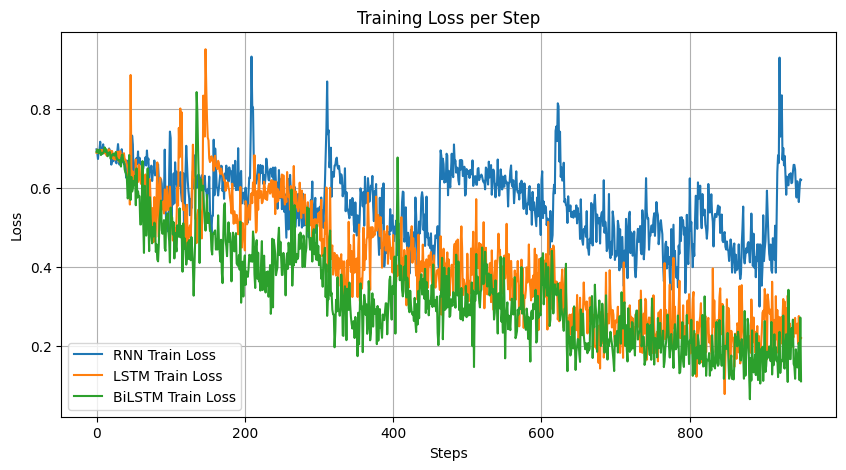

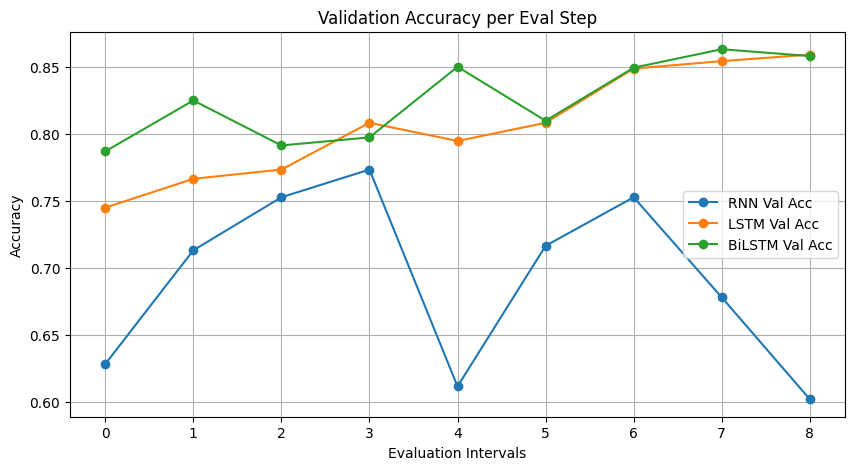

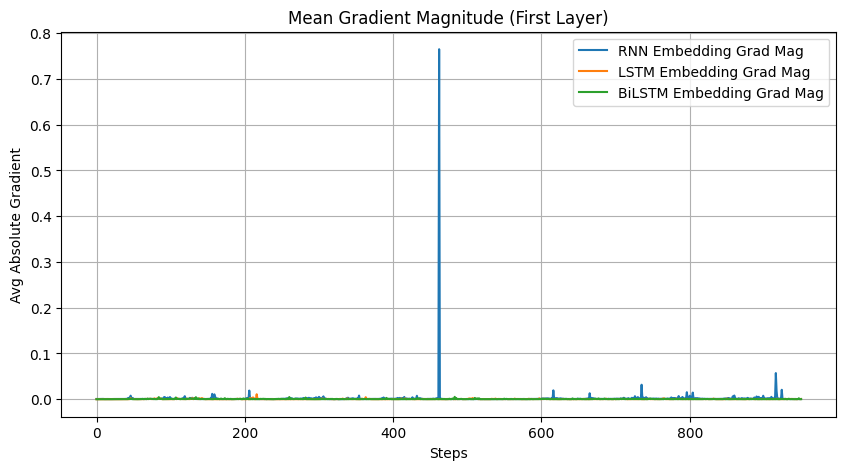

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Training Loss
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['train_loss'], label=f"{name} Train Loss")
plt.title("Training Loss per Step")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Validation Accuracy
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['val_acc'], label=f"{name} Val Acc", marker='o')
plt.title("Validation Accuracy per Eval Step")
plt.xlabel("Evaluation Intervals")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 3. Plot Gradient Magnitudes
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]['grads'], label=f"{name} Embedding Grad Mag")
plt.title("Mean Gradient Magnitude (First Layer)")
plt.xlabel("Steps")
plt.ylabel("Avg Absolute Gradient")
plt.legend()
plt.grid(True)
plt.show()